In [1]:
# Aqui se cargaron las librerías necesarias.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Librerías para modelos de ciencia de datos.
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#Se importa lectura de datos en Python y lo cargamos en la variable de Datos.
Datos = pd.read_csv('C:/Unad/car details v4.csv')

In [3]:
#Aqui se realizo una lectura de datos para el aanalisis exploratorio
Datos.head(12)

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0
5,Maruti Suzuki,Ciaz ZXi,675000,2017,73315,Petrol,Manual,Pune,Grey,First,Individual,1373 cc,91 bhp @ 6000 rpm,130 Nm @ 4000 rpm,FWD,4490.0,1730.0,1485.0,5.0,43.0
6,Mercedes-Benz,CLA 200 Petrol Sport,1898999,2015,47000,Petrol,Automatic,Mumbai,White,Second,Individual,1991 cc,181 bhp @ 5500 rpm,300 Nm @ 1200 rpm,FWD,4630.0,1777.0,1432.0,5.0,NaN
7,BMW,X1 xDrive20d M Sport,2650000,2017,75000,Diesel,Automatic,Coimbatore,White,Second,Individual,1995 cc,188 bhp @ 4000 rpm,400 Nm @ 1750 rpm,AWD,4439.0,1821.0,1612.0,5.0,51.0
8,Skoda,Octavia 1.8 TSI Style Plus AT [2017],1390000,2017,56000,Petrol,Automatic,Mumbai,White,First,Individual,1798 cc,177 bhp @ 5100 rpm,250 Nm @ 1250 rpm,FWD,4670.0,1814.0,1476.0,5.0,50.0
9,Nissan,Terrano XL (D),575000,2015,85000,Diesel,Manual,Mumbai,White,First,Individual,1461 cc,84 bhp @ 3750 rpm,200 Nm @ 1900 rpm,FWD,4331.0,1822.0,1671.0,5.0,50.0


In [4]:
#Aqui muestra la descripcion de las caracteristicas de los Datos.
Datos.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


In [6]:
#Revisar valores nulos: Esto nos permite saber qué columnas tienen datos faltantes
print(Datos.isnull().sum())

Make                    0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64


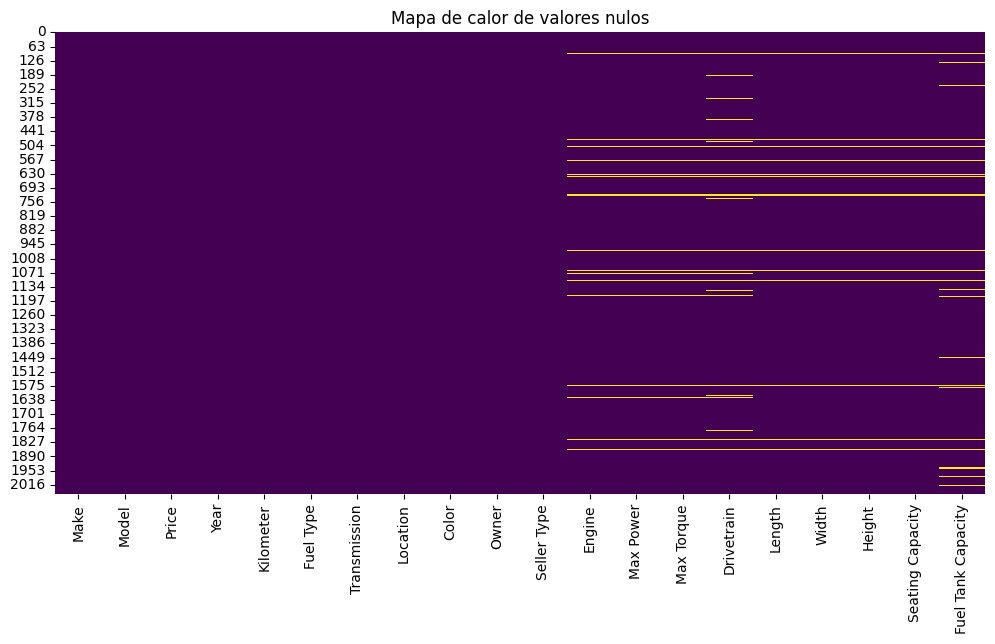

In [7]:
# Tambien lo Podemos  visualizarlos también con un mapa de calor:
plt.figure(figsize=(12,6))
sns.heatmap(Datos.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de calor de valores nulos')
plt.show()

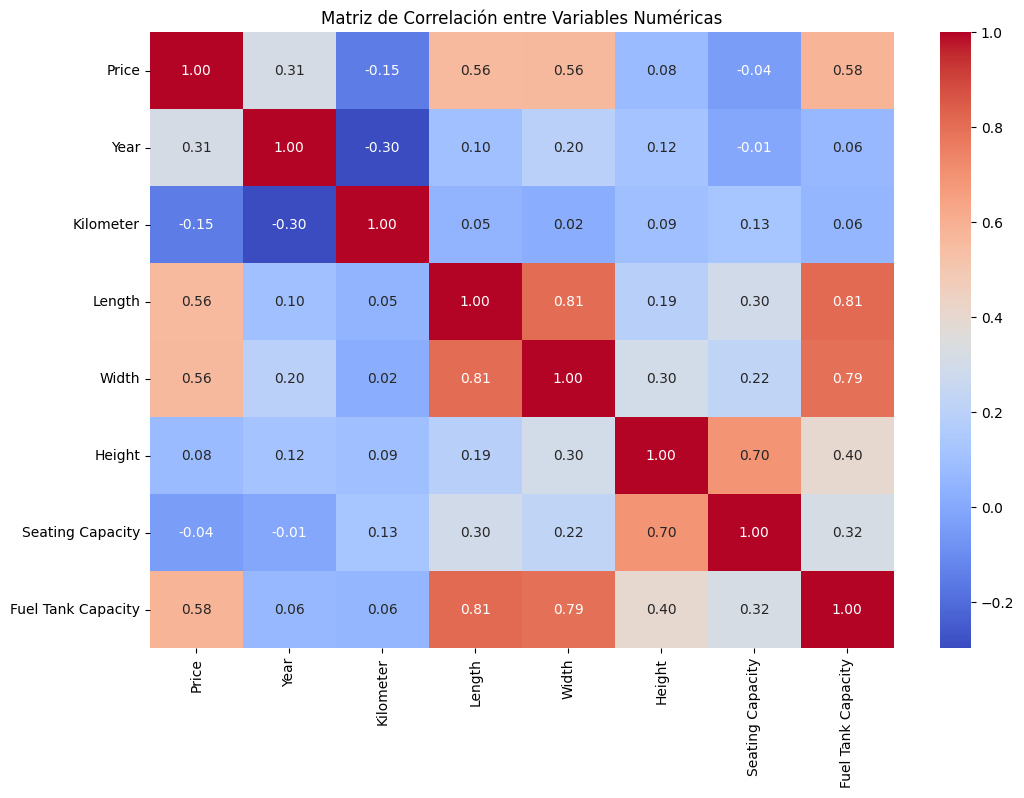

In [8]:
# Selección de columnas numéricas, Aqui se muestra la identificacion de las relaciones entre variables, Correlación entre variables numéricas.
numericas = Datos.select_dtypes(include=np.number)

# Matriz de correlación
plt.figure(figsize=(12,8))
sns.heatmap(numericas.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación entre Variables Numéricas')
plt.show()

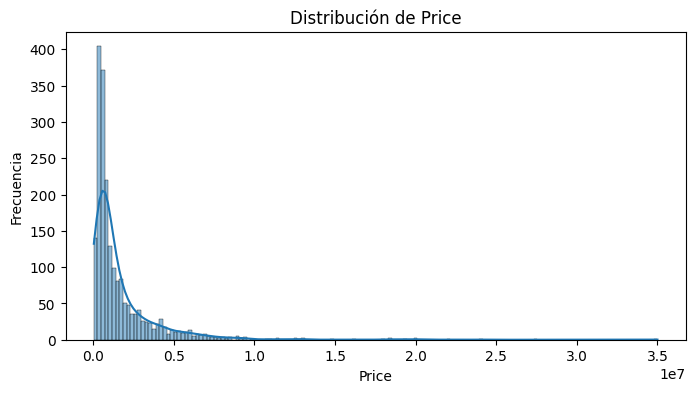

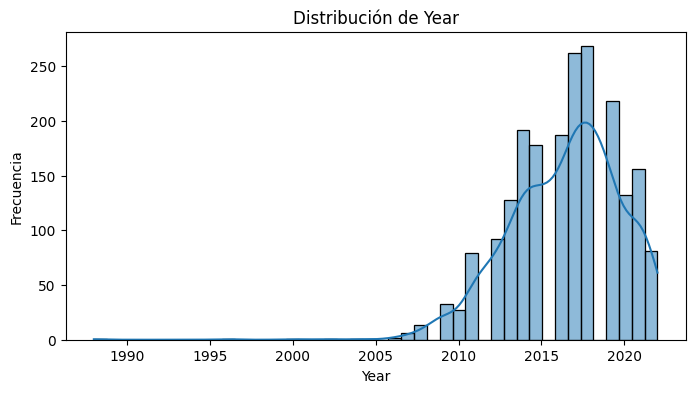

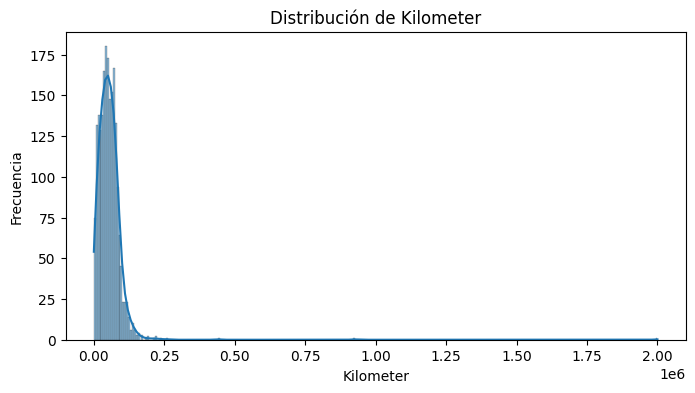

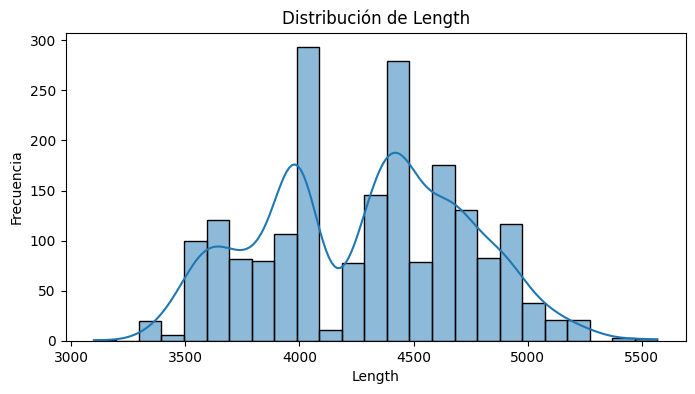

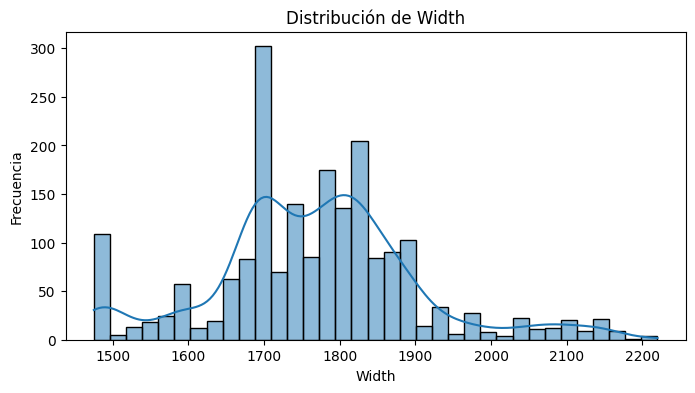

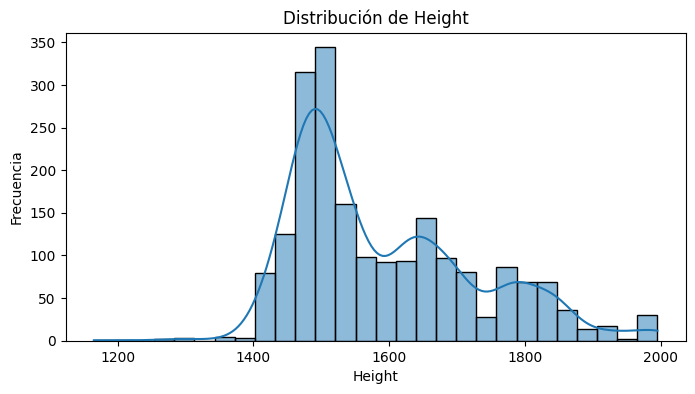

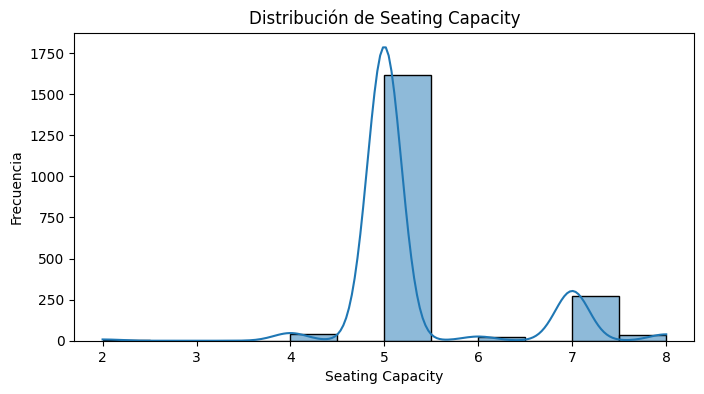

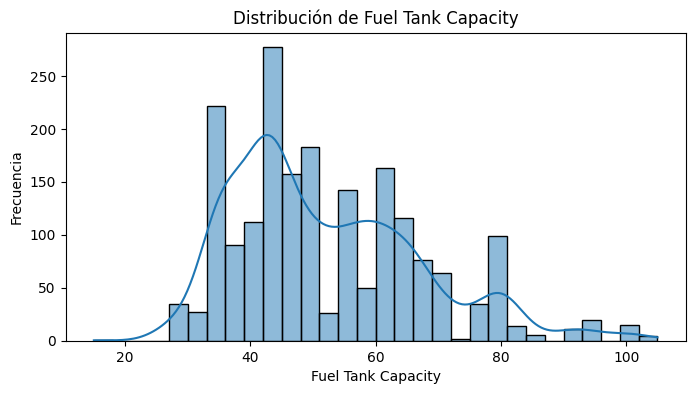

In [10]:
# Aqui se muestra la Distribución de variables numéricas
columnas_numericas = ['Price', 'Year', 'Kilometer', 'Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity']

for col in columnas_numericas:
    plt.figure(figsize=(8,4))
    sns.histplot(Datos[col].dropna(), kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

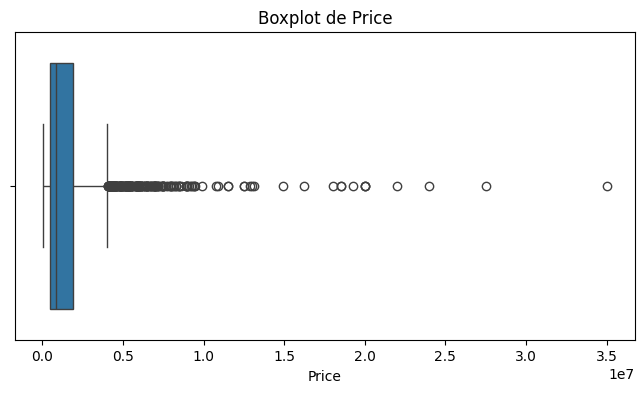

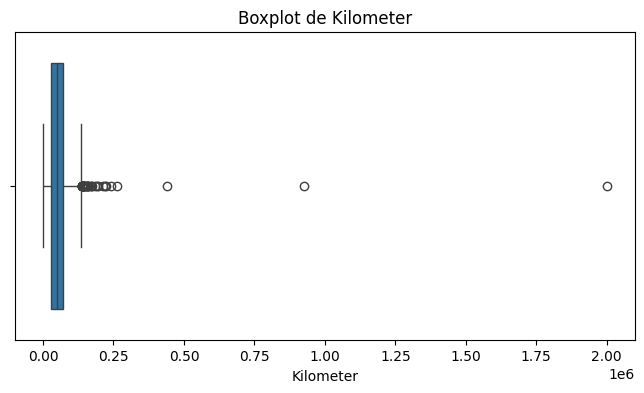

In [12]:
#Detección de valores atípicos
for col in ['Price', 'Kilometer']:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=Datos[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

In [13]:
# Paso 2: Procesar los datos limpiándolos, tratando valores faltantes ytransformándolos según sea necesario. 
print(Datos.isnull().sum())

# Eliminamos columnas no numéricas o irrelevantes para la regresión lineal
Datos_limpios = Datos.copy()

# Convertimos 'Engine' y 'Max Power' a valores numéricos extrayendo los números
Datos_limpios['Engine'] = Datos_limpios['Engine'].str.replace(' cc', '').astype(float)
Datos_limpios['Max Power'] = Datos_limpios['Max Power'].str.extract('(\d+\.?\d*)').astype(float)

# Rellenamos valores faltantes con la media (opcionalmente, se pueden eliminar)
Datos_limpios['Fuel Tank Capacity'].fillna(Datos_limpios['Fuel Tank Capacity'].mean(), inplace=True)
Datos_limpios['Engine'].fillna(Datos_limpios['Engine'].mean(), inplace=True)
Datos_limpios['Max Power'].fillna(Datos_limpios['Max Power'].mean(), inplace=True)

# Eliminamos columnas categóricas que no vamos a usar
columnas_a_eliminar = ['Make', 'Model', 'Fuel Type', 'Transmission', 'Location', 'Color', 'Owner', 'Seller Type', 'Max Torque', 'Drivetrain']
Datos_limpios.drop(columns=columnas_a_eliminar, inplace=True)

# Verificamos que no queden valores faltantes
print(Datos_limpios.isnull().sum())


Make                    0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64
Price                  0
Year                   0
Kilometer              0
Engine                 0
Max Power              0
Length                64
Width                 64
Height                64
Seating Capacity      64
Fuel Tank Capacity     0
dtype: int64


<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
C:\Users\alexi\AppData\Local\Temp\ipykernel_7996\3165734272.py:9: SyntaxWarning: invalid escape sequence '\d'
  Datos_limpios['Max Power'] = Datos_limpios['Max Power'].str.extract('(\d+\.?\d*)').astype(float)
C:\Users\alexi\AppData\Local\Temp\ipykernel_7996\3165734272.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Datos_limpios['Fuel Tank Capacity'].fillna(Datos_limpios['Fuel Tank Capacity'].mean(), inplace=True)
C:\Users\

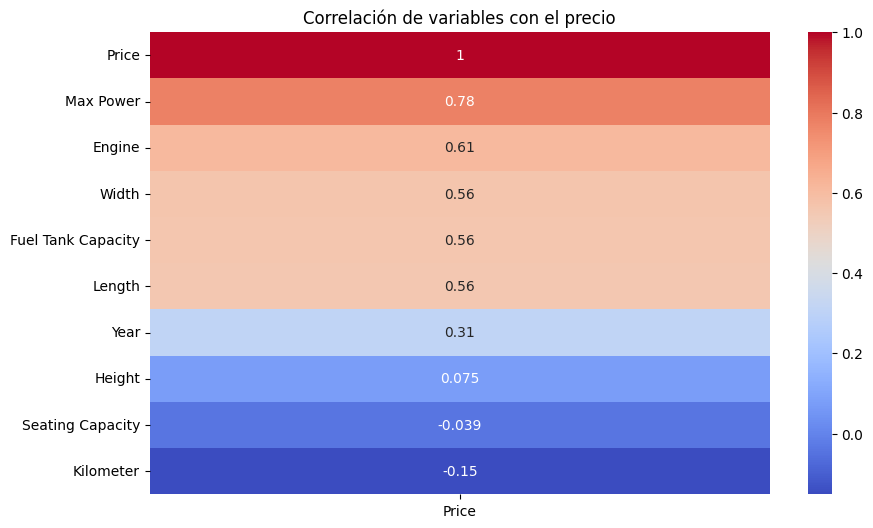

In [15]:
# Paso3: Seleccionar las características más relevantes para entrenar el modelo utilizando selección de características.
correlaciones = Datos_limpios.corr()

# Visualizamos la correlación con 'Price'
plt.figure(figsize=(10,6))
sns.heatmap(correlaciones[['Price']].sort_values(by='Price', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlación de variables con el precio')
plt.show()

# Seleccionamos las variables más correlacionadas
caracteristicas = ['Year', 'Kilometer', 'Engine', 'Max Power', 'Seating Capacity', 'Fuel Tank Capacity']

In [16]:
# Paso4: Dividir el dataset en Train y Test para evaluar correctamente el modelo.
# Definimos variables independientes (X) y dependiente (y)
X = Datos_limpios[caracteristicas]
y = Datos_limpios['Price']

# Dividimos los datos: 80% para entrenamiento, 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
print(X_train)

      Year  Kilometer       Engine   Max Power  Seating Capacity  \
266   2012      75576  1692.575543  129.611774               NaN   
1133  2016      77000  1995.000000  184.000000               5.0   
1823  2017     112000  1997.000000  138.000000               7.0   
1370  2021       3000  2925.000000  326.000000               7.0   
67    2019      73000  2755.000000  174.000000               7.0   
...    ...        ...          ...         ...               ...   
1638  2016      92000  1248.000000   89.000000               5.0   
1095  2014       9212  1692.575543  129.611774               NaN   
1130  2017      16800   998.000000   67.000000               5.0   
1294  2014      68000  1995.000000  217.000000               5.0   
860   2018      12768  1196.000000   73.000000               5.0   

      Fuel Tank Capacity  
266             52.00221  
1133            63.00000  
1823            70.00000  
1370            90.00000  
67              80.00000  
...                  

In [18]:
print(X_test)

      Year  Kilometer       Engine   Max Power  Seating Capacity  \
1298  2017      35000  2993.000000  258.000000               7.0   
591   2018      48174  1248.000000   89.000000               5.0   
1318  2016      68921  1248.000000   74.000000               5.0   
1067  2019      32809  1598.000000  105.000000               5.0   
29    2018      27963  1199.000000   89.000000               5.0   
...    ...        ...          ...         ...               ...   
1033  2011      80000  1692.575543  129.611774               NaN   
674   2013     104264  1995.000000  188.000000               5.0   
1771  2015      33000  1692.575543  129.611774               NaN   
322   2015      67738   998.000000   58.000000               5.0   
1299  2017      44000  1493.000000  100.000000               7.0   

      Fuel Tank Capacity  
1298            52.00221  
591             48.00000  
1318            37.00000  
1067            55.00000  
29              40.00000  
...                  

In [22]:
# Paso5: Entrenar el modelo configurando los diferentes hiperparámetros
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [32]:
# Se volvieron a Cargar los datos 
Datos = pd.read_csv('C:/Unad/car details v4.csv')

# Ver los primeros registros
print(Datos.head())

# Revisar valores faltantes
print(Datos.isnull().sum())

            Make                            Model    Price  Year  Kilometer  \
0          Honda              Amaze 1.2 VX i-VTEC   505000  2017      87150   
1  Maruti Suzuki                  Swift DZire VDI   450000  2014      75000   
2        Hyundai             i10 Magna 1.2 Kappa2   220000  2011      67000   
3         Toyota                         Glanza G   799000  2019      37500   
4         Toyota  Innova 2.4 VX 7 STR [2016-2020]  1950000  2018      69000   

  Fuel Type Transmission   Location   Color   Owner Seller Type   Engine  \
0    Petrol       Manual       Pune    Grey   First   Corporate  1198 cc   
1    Diesel       Manual   Ludhiana   White  Second  Individual  1248 cc   
2    Petrol       Manual    Lucknow  Maroon   First  Individual  1197 cc   
3    Petrol       Manual  Mangalore     Red   First  Individual  1197 cc   
4    Diesel       Manual     Mumbai    Grey   First  Individual  2393 cc   

            Max Power              Max Torque Drivetrain  Length   W

In [25]:
# Aqui se convirtieron las variables categóricas a numéricas (One Hot Encoding)
Datos_procesados = pd.get_dummies(Datos_filled, drop_first=True)

In [26]:
# Aqui se Reemplaza 'Price' por el nombre de tu variable objetivo
X = Datos_procesados.drop('Price', axis=1)
y = Datos_procesados['Price']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
modelo_rl = LinearRegression()
modelo_rl.fit(X_train, y_train)

LinearRegression()

In [29]:
y_pred = modelo_rl.predict(X_test)

In [30]:
# El Error cuadrático medio (MSE) y R^2
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")

Error cuadrático medio (MSE): 44486913849879.34
Coeficiente de determinación (R²): -5.37


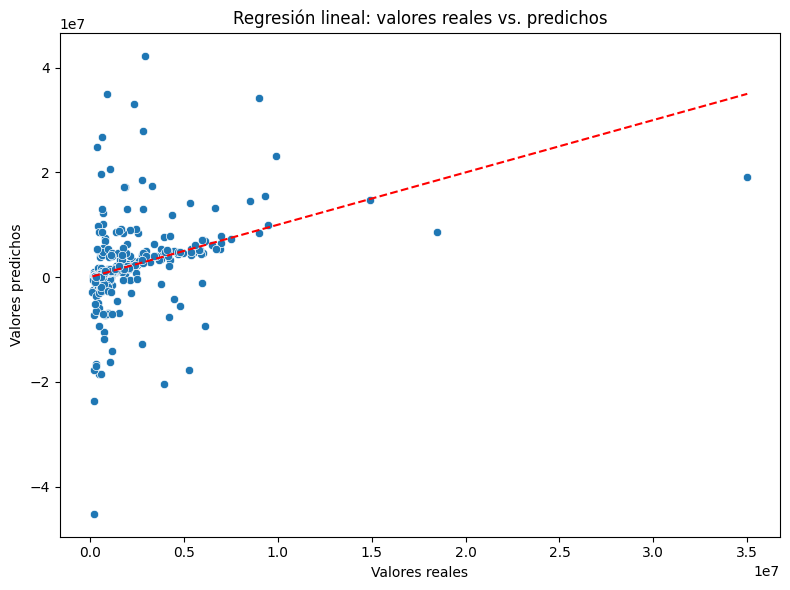

In [31]:
# Aqui se compararon los valores reales vs. predichos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Regresión lineal: valores reales vs. predichos")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.tight_layout()
plt.show()

In [33]:
# Paso6: Evaluar el desempeño del modelo en el conjunto de Test con métricas como precisión, recall, F1-score, etc.
# En regresión lineal no usamos precisión, recall o F1-score, ya que esas métricas son para clasificación. En su lugar, usamos:
#R2 score (explica qué tanto del precio se predice)
#Error cuadrático medio (MSE)
#Raíz del error cuadrático medio (RMSE)
# Predicciones
y_pred = modelo_rl.predict(X_test)

# Métricas
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error (RMSE):", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: -5.367752210024859
Mean Squared Error (MSE): 44486913849879.336
Root Mean Squared Error (RMSE): 6669851.111522606


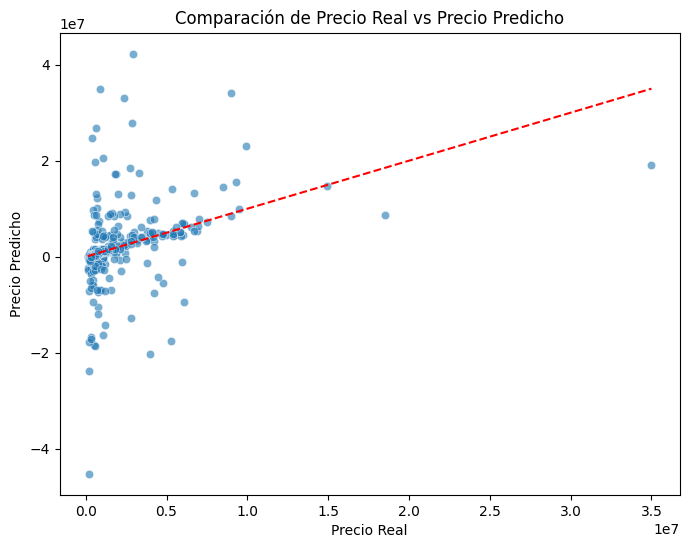

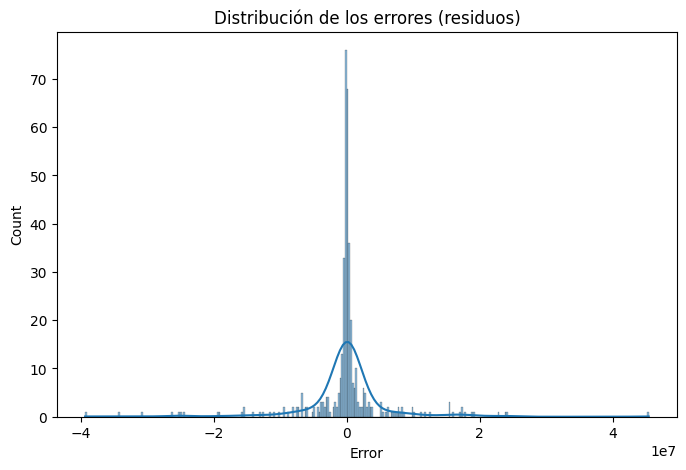

In [34]:
# Paso7: Realizar las diferentes gráficas que permitan visualizar los resultados del modelo.

# Gráfico: valores reales vs predichos
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Comparación de Precio Real vs Precio Predicho")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

# Gráfico de residuales
residuos = y_test - y_pred
plt.figure(figsize=(8,5))
sns.histplot(residuos, kde=True)
plt.title("Distribución de los errores (residuos)")
plt.xlabel("Error")
plt.show()